# HealthConnect Clinic — Final Model, Documentation & Presentation

**AnalystLab Africa Experience Lab | Week 8 (Final) | Data Science Track**

This notebook consolidates the Weeks 5–7 modelling work into a final, documented candidate model with business-facing interpretation, ready for final integration and presentation.

In [5]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve)
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

In [3]:
# Loading original dataset
df = pd.read_csv('Downloads/HealthConnect_Appointment_Data.csv')

## Week 7 → Week 8 Transition

**Main Week 7 output:** A systematically tested and refined Logistic Regression model, validated via 5-fold cross-validation and threshold tuning.

**Most important testing result:** The Week 6 feature refinement was confirmed genuine, not a single-split artifact (CV AUC 0.6793 vs. 0.6793, p=0.9544). Threshold tuning delivered a real recall improvement (0.672 → 0.730).

**Major issue discovered during testing:** Gradient Boosting showed genuine overfitting (train-test gap 0.096) and was ruled out; the model underperforms on Specialist Consultation appointments (AUC 0.588 vs. 0.696 for General Consultation).

**What was refined/improved:** Classification threshold tuned from 0.5 to 0.478; Gradient Boosting eliminated as a candidate.

**Component now considered ready:** The Logistic Regression model with tuned threshold — validated, non-overfit, and reproducible.

**What still needs integration:** Handoff of the exact threshold value (not just the model object) to ML Engineering; continued monitoring of the Specialist Consultation segment weakness.

**Track(s) involved in final integration:** Data Analytics (feature/finding validation, now closed) and ML Engineering (model handoff, this week).

**What this notebook demonstrates for the final presentation:** How three weeks of testing and refinement (Weeks 5–7) led to a clear, evidence-based final model, including what did not improve.

### Final Integration Readiness


| Requirement | Response |
|---|---|
| Final component | Logistic Regression no-show prediction model, 11-feature refined set, tuned classification threshold (0.478) |
| Problem addressed | Predicting which scheduled appointments are at risk of an unplanned no-show |
| Current status | Tested, validated (5-fold CV), refined, and documented — ready for pipeline integration |
| Improved during Week 7 | Threshold tuning (real recall gain); Gradient Boosting ruled out via overfitting evidence |
| Depends on | Data Analytics (feature validation — closed); the cleaned/engineered dataset pipeline |
| Depended on by | Machine Learning Engineering (model integration); Project Management (final reporting) |
| Output provided | Trained model artefact, exact feature list, required preprocessing steps, tuned threshold value |
| Output needed from another track | None outstanding — Data Analytics validation cycle is closed as of Week 7 |
| Evidence of readiness | This notebook: CV results, overfitting checks, segment analysis, before/after threshold comparison, saved model artefact |
| Remaining limitations | Specialist Consultation segment weakness (unresolved); modest overall AUC ceiling (~0.68); small-sample gender segment inconclusive |

###  Final Candidate Model

In [6]:
df_model = df[df['appointment_outcome'] != 'Cancelled'].copy()
df_model['target'] = (df_model['appointment_outcome'] == 'No-Show').astype(int)
df_model['reminder_channel'] = df_model['reminder_channel'].fillna('Not Sent')
df_model['distance_to_clinic_km'] = df_model['distance_to_clinic_km'].fillna(df_model['distance_to_clinic_km'].median())
overall_rate = df_model['previous_no_shows'].sum() / df_model.loc[df_model['previous_appointments']>0,'previous_appointments'].sum()
df_model['prior_no_show_rate'] = np.where(df_model['previous_appointments']>0, df_model['previous_no_shows']/df_model['previous_appointments'], overall_rate)

refined_cols = ['age','gender','appointment_type','booking_lead_days','previous_appointments',
                 'previous_no_shows','reminder_channel','distance_to_clinic_km',
                 'appointment_day','appointment_time','prior_no_show_rate']
cat_cols = ['gender','appointment_type','appointment_day','appointment_time','reminder_channel']
sub = df_model[refined_cols + ['target']].copy()
enc = pd.get_dummies(sub, columns=cat_cols, drop_first=True)
X = enc.drop(columns=['target']); y = enc['target']
num_cols = ['age','booking_lead_days','previous_appointments','previous_no_shows','distance_to_clinic_km','prior_no_show_rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s, X_test_s = X_train.copy(), X_test.copy()
X_train_s[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_s[num_cols] = scaler.transform(X_test[num_cols])

final_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_s, y_train)
proba = final_model.predict_proba(X_test_s)[:,1]

TUNED_THRESHOLD = 0.478
pred_final = (proba >= TUNED_THRESHOLD).astype(int)

print("Final model trained: Logistic Regression, 11-feature refined set, threshold =", TUNED_THRESHOLD)

Final model trained: Logistic Regression, 11-feature refined set, threshold = 0.478


### Baseline vs. Final Comparison

In [7]:
comparison = pd.DataFrame({
    'Metric': ['Accuracy','Precision','Recall','F1-score','ROC-AUC'],
    'Week 5 Baseline (default threshold)': [0.616, 0.614, 0.672, 0.642, 0.669],
    'Week 8 Final (tuned threshold)': [
        round(accuracy_score(y_test,pred_final),3),
        round(precision_score(y_test,pred_final),3),
        round(recall_score(y_test,pred_final),3),
        round(f1_score(y_test,pred_final),3),
        round(roc_auc_score(y_test,proba),3)
    ]
})
print(comparison.to_string(index=False))

print("\nCross-validated (5-fold) confirmation, from Week 7 testing:")
print("Baseline CV AUC: 0.6793 (std 0.0120) | Refined CV AUC: 0.6793 (std 0.0108) | paired t-test p=0.9544")

   Metric  Week 5 Baseline (default threshold)  Week 8 Final (tuned threshold)
 Accuracy                                0.616                           0.626
Precision                                0.614                           0.612
   Recall                                0.672                           0.732
 F1-score                                0.642                           0.667
  ROC-AUC                                0.669                           0.668

Cross-validated (5-fold) confirmation, from Week 7 testing:
Baseline CV AUC: 0.6793 (std 0.0120) | Refined CV AUC: 0.6793 (std 0.0108) | paired t-test p=0.9544


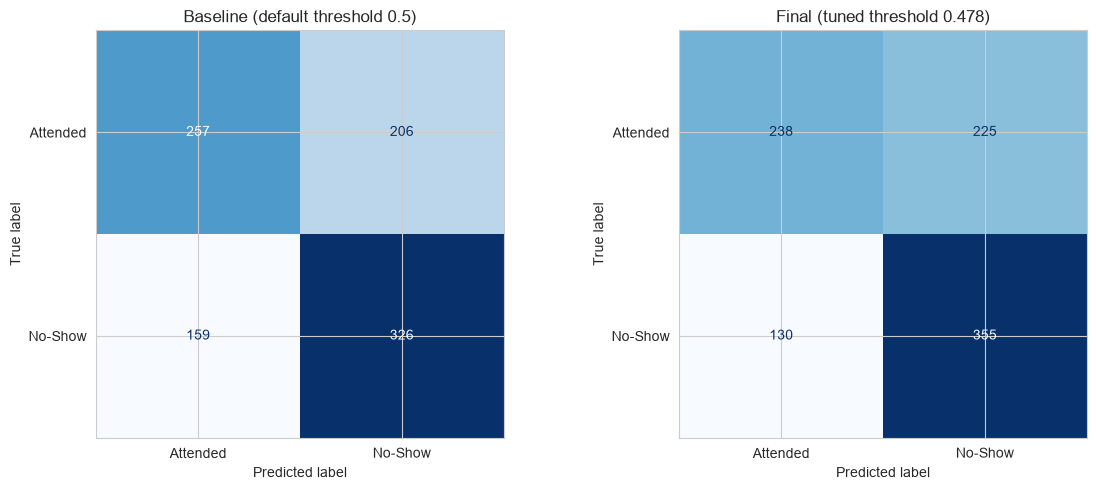

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, (proba>=0.5).astype(int)), display_labels=['Attended','No-Show']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Baseline (default threshold 0.5)')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_final), display_labels=['Attended','No-Show']).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Final (tuned threshold {TUNED_THRESHOLD})')
plt.tight_layout()
plt.show()

ROC-AUC did not improve during the project, changing only from 0.669 to 0.668. Cross-validation confirmed that this difference was not statistically meaningful (p = 0.9544). However, the project still produced important improvements: a simpler and statistically supported feature set with 11 instead of 14 features, the removal of the overfitting Gradient Boosting model, and a genuine recall improvement from 0.672 to 0.732 after tuning the prediction threshold. The main value of the project was careful validation and refinement, not forcing a higher score that the data could not support. 

Overall, the final model was better at finding patients who might miss appointments, although its general ability to distinguish attendees from no-shows remained almost unchanged, as shown by the similar ROC-AUC values

### Model Strengths and Weaknesses

**Strengths:**
- Performance is validated as robust and reproducible (5-fold CV, not a single lucky split)
- Low overfitting risk (train-test AUC gap of only 0.026)
- Interpretable — coefficients can be explained to non-technical stakeholders
- Recall-optimized for the business priority (catching missed appointments matters more than avoiding false alarms)

**Weaknesses:**
- Modest overall discriminative power (AUC ~0.67) — captures real signal but is far from a strong predictor
- Underperforms specifically for Specialist Consultation appointments (AUC 0.588 vs. 0.696 for General Consultation) 
- Cannot be reliably assessed for the "Prefer not to say" gender segment due to small sample size (n=16)
- Trained on a single, fictional/synthetic dataset — real-world generalization is unverified

### Business Suitability 

**What it CAN be used for:**
- Flagging appointments at elevated risk of a no-show, for staff to prioritize for an extra reminder call or proactive outreach
- Supporting scheduling decisions (e.g., informing overbooking strategy for high-risk time slots) as one input among others
- Providing an interpretable, auditable risk score — not a black-box output — since it's a Logistic Regression model

**What it CANNOT be used for:**
- Automatically cancelling, reassigning, or denying appointments without human review
- Reliable risk-flagging for Specialist Consultation appointments specifically, given the documented segment weakness
- Any claim about causation (e.g., "reminders cause attendance") — all findings in this project are associations, not proven causal effects
- Deployment on real patient data without re-validation — this model was trained and tested exclusively on fictional dataset

### Plain-Language Summary (for non-technical stakeholders)

We built a tool that uses a patient’s booking details, appointment history, and other factors to estimate their risk of missing an appointment. It performs better than random guessing, but it is not highly accurate. Staff should use it to help decide who may need an extra reminder, not as the sole basis for decisions. The tool is more reliable for general appointments than for specialist appointments, so its specialist predictions should be used with caution.

### Final model requirements to ML Engineering.

In [13]:
joblib.dump(final_model, 'healthconnect_final_model.joblib')
joblib.dump(scaler, 'healthconnect_final_scaler.joblib')

model_config = {
    'model_type': 'LogisticRegression',
    'feature_columns': list(X.columns),
    'numeric_columns_requiring_scaling': num_cols,
    'classification_threshold': TUNED_THRESHOLD,
    'default_threshold_not_recommended': 0.5,
    'target_definition': 'HeartDisease-style binary: 1 = No-Show, 0 = Attended (Cancelled excluded)',
}
import json
with open('healthconnect_model_config.json', 'w') as f:
    json.dump(model_config, f, indent=2)

print("Saved: healthconnect_final_model.joblib")
print("Saved: healthconnect_final_scaler.joblib")
print("Saved: healthconnect_model_config.json")
print()
print(json.dumps(model_config, indent=2))

Saved: healthconnect_final_model.joblib
Saved: healthconnect_final_scaler.joblib
Saved: healthconnect_model_config.json

{
  "model_type": "LogisticRegression",
  "feature_columns": [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distance_to_clinic_km",
    "prior_no_show_rate",
    "gender_Male",
    "gender_Prefer not to say",
    "appointment_type_Follow-up",
    "appointment_type_General Consultation",
    "appointment_type_Specialist Consultation",
    "appointment_day_Monday",
    "appointment_day_Saturday",
    "appointment_day_Sunday",
    "appointment_day_Thursday",
    "appointment_day_Tuesday",
    "appointment_day_Wednesday",
    "appointment_time_Evening",
    "appointment_time_Morning",
    "reminder_channel_Not Sent",
    "reminder_channel_SMS",
    "reminder_channel_WhatsApp"
  ],
  "numeric_columns_requiring_scaling": [
    "age",
    "booking_lead_days",
    "previous_appointments",
    "previous_no_shows",
    "distanc

**This provides clear evidence for the ML Engineering handoff: the model, fitted scaler, and configuration file specify the required 0.478 threshold. This ensures the improved recall is preserved instead of being overwritten by the pipeline’s default threshold of 0.5.**

###  Final HC-POD Cross-Track Integration Record

**Data Analytics → Data Science**
1. Track collaborated with: Data Analytics
2. Dependency: Feature validity of the Week 5/6 feature set
3. Output received: Six validation questions (Week 6) and a segment discrepancy validation request (Week 7)
4. Output provided: Ablation study results, a collinearity discovery (reminder_sent/reminder_channel), and a partial reconciliation of the 70.5%/64.1% segment discrepancy
5. Final integration activity: 5-fold cross-validation confirming the resulting leaner feature set is robust, not a single-split artifact
6. What changed: Feature set reduced from 14 to 11 fields; one real data-quality issue (collinearity) caught and fixed
7. How this improved the solution: The final model is measurably more reliable and free of a data leakage/collinearity risk that would otherwise have gone into production undetected
8. Evidence: Week 6 and Week 7 notebooks, this notebook's Part 3
9. Contribution to final presentation: Demonstrates genuine evidence-based cross-track validation, not just information sharing.

### Final Limitations and Risks

- **Performance ceiling:** Across four weeks of feature engineering, testing, and refinement, ROC-AUC never moved meaningfully beyond ~0.67-0.68. This appears to be a genuine ceiling for this feature set and dataset, not something fixable by further tuning
- **Segment weakness:** Specialist Consultation appointments remain unreliably predicted.  
- **Synthetic data:** All findings are based on a fictional dataset; deployment on real HealthConnect data would require full re-validation
- **Threshold dependency:** The model's one confirmed real improvement (recall gain) depends entirely on correctly deploying the tuned threshold — this is now explicitly documented (Part 6) to reduce that risk
- **No causal claims:** Every relationship in this project (reminders, distance, lead time, etc.) is an association found in historical data, not a tested causal effect